In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (20, 12),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts_builder = TimeseriesBuilder()

In [26]:
start = NYC_tz.localize(datetime.datetime(2021, 1, 1, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 3, 24, 17, 00))

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="7Y/20Y",
            value=UnifiedValue.IRS_SPREADOVER,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="7Y",
            value=UnifiedValue.IRS_SPREADOVER,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="20Y",
            value=UnifiedValue.IRS_SPREADOVER,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="7Y",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="20Y",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            cusip="CT7",
            value=UnifiedValue.FRB_YTM,
        ),
        UnifiedQuery(
            cusip="CT20",
            value=UnifiedValue.FRB_YTM,
        ),
    ],
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

WARNING	Task(Task-4) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
WARNING	Task(Task-4) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


READING USD-SOFR-1D computed cache...:   0%|          | 0/2 [00:00<?, ?it/s]

READING USD-SOFR-1D curve analytics...:   0%|          | 0/1305 [00:00<?, ?it/s]

FETCHING PRICERS: 100%|██████████| 252/252 [00:11<00:00, 22.81it/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

WRITING USD-SOFR-1D computed cache...:   0%|          | 0/2 [00:00<?, ?it/s]

FETCHING PRICERS:  18%|█▊        | 46/252 [00:01<00:04, 45.67it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

PRICING USD-SOFR-1D IRSWAPS [workers=12]...: 100%|██████████| 756/756 [01:19<00:00,  9.45it/s]


,USD-SOFR-1D 20Y OUTRIGHT RATE,USD-SOFR-1D 7Y OUTRIGHT RATE,CT20 OUTRIGHT YTM,CT7 OUTRIGHT YTM,USD-SOFR-1D 7Y/20Y CURVE SPREADOVER,USD-SOFR-1D 7Y OUTRIGHT SPREADOVER,USD-SOFR-1D 20Y OUTRIGHT SPREADOVER
Date,,,,,,,
2021-01-04,1.087744,0.455423,1.451267,0.638738,-18.021463,-18.332977,-36.354440
2021-01-05,1.131640,0.488850,1.488015,0.661687,-18.353822,-17.285747,-35.639569
2021-01-06,1.221824,0.551105,1.594200,0.735412,-18.807374,-18.432463,-37.239838
2021-01-07,1.249374,0.590390,1.637695,0.772475,-20.625187,-18.209623,-38.834810
2021-01-08,1.287092,0.634654,1.668255,0.809810,-20.602156,-17.516751,-38.118907
...,...,...,...,...,...,...,...
2026-03-18,4.093167,3.639220,4.859004,4.051372,-35.370338,-41.205528,-76.585908
2026-03-19,4.054980,3.682493,4.851000,4.091000,-38.752054,-40.849994,-79.602048
2026-03-20,4.176636,3.783844,4.986000,4.208000,-38.519125,-42.417150,-80.936274


In [27]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot(df["USD-SOFR-1D 7Y/20Y CURVE SPREADOVER"])
plot(df["USD-SOFR-1D 7Y OUTRIGHT SPREADOVER"], which="right")
plot(df["USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"], which="right")
legend(show_date=True)
plt.show()

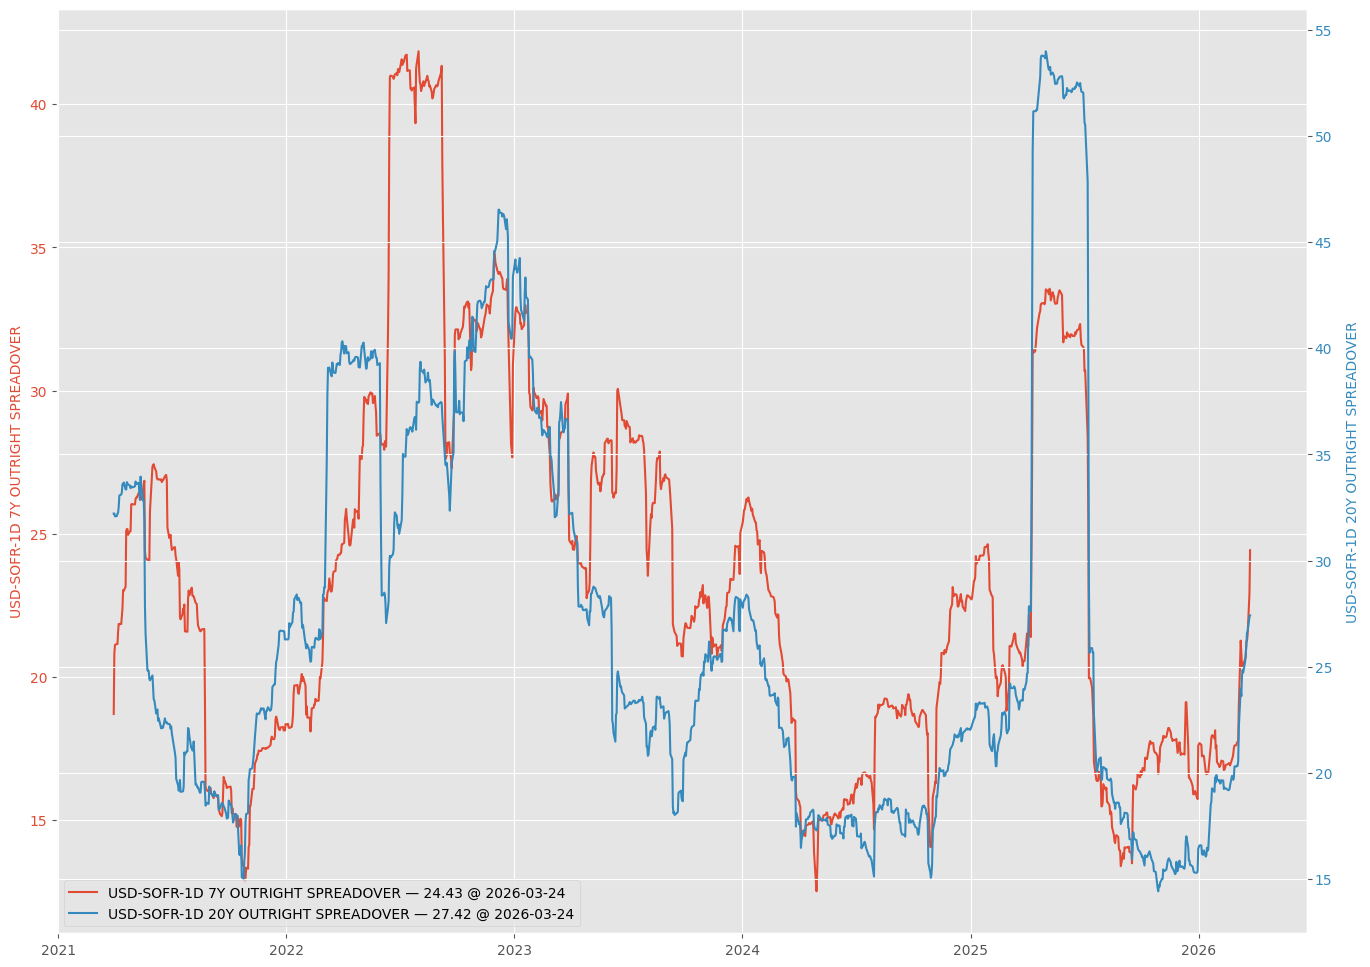

In [36]:
import gs_quant.timeseries.econometrics as gsqtse

from RVUtils.plt_timeseries import make_secondary_axis_plot

plot, fig, ax, ax2, legend = make_secondary_axis_plot()
	
rv1 = gsqtse.volatility(x=df["USD-SOFR-1D 7Y OUTRIGHT SPREADOVER"], w=60, returns_type=gsqtse.Returns.ABSOLUTE) / 100
rv2 = gsqtse.volatility(x=df["USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"], w=60, returns_type=gsqtse.Returns.ABSOLUTE) / 100

plot(
    rv1,
    which="left",
    indicators=[
        # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        # {"kind": "sma", "window": 252, "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
		# {"kind": "hurst", "hide": True},
		# {"kind": "vol", "returns": "normal", "window": 252, "hide": True},
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)
plot(
    rv2,
    which="right",
)

# plot(d["USD-SOFR-1D 2Y OUTRIGHT RATE"])

legend(show_date=True, loc="lower left")
plt.show()

Beta: [0.00118599 0.71061825]
Beta Std Error: [0.0290549  0.02298891]
Beta Covariance: [[9697.4857376   103.32387152]
 [ 103.32387152 6070.95942115]]
Residual Variance: 8.705217265024932e-08
Inverse Condition #: 0.8653336046826745
Reason(s) for Halting:
  Sum of squares convergence


c:\Users\chris\clee\ARBS\notebooks\rv\../..\RVUtils\regression.py:854: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



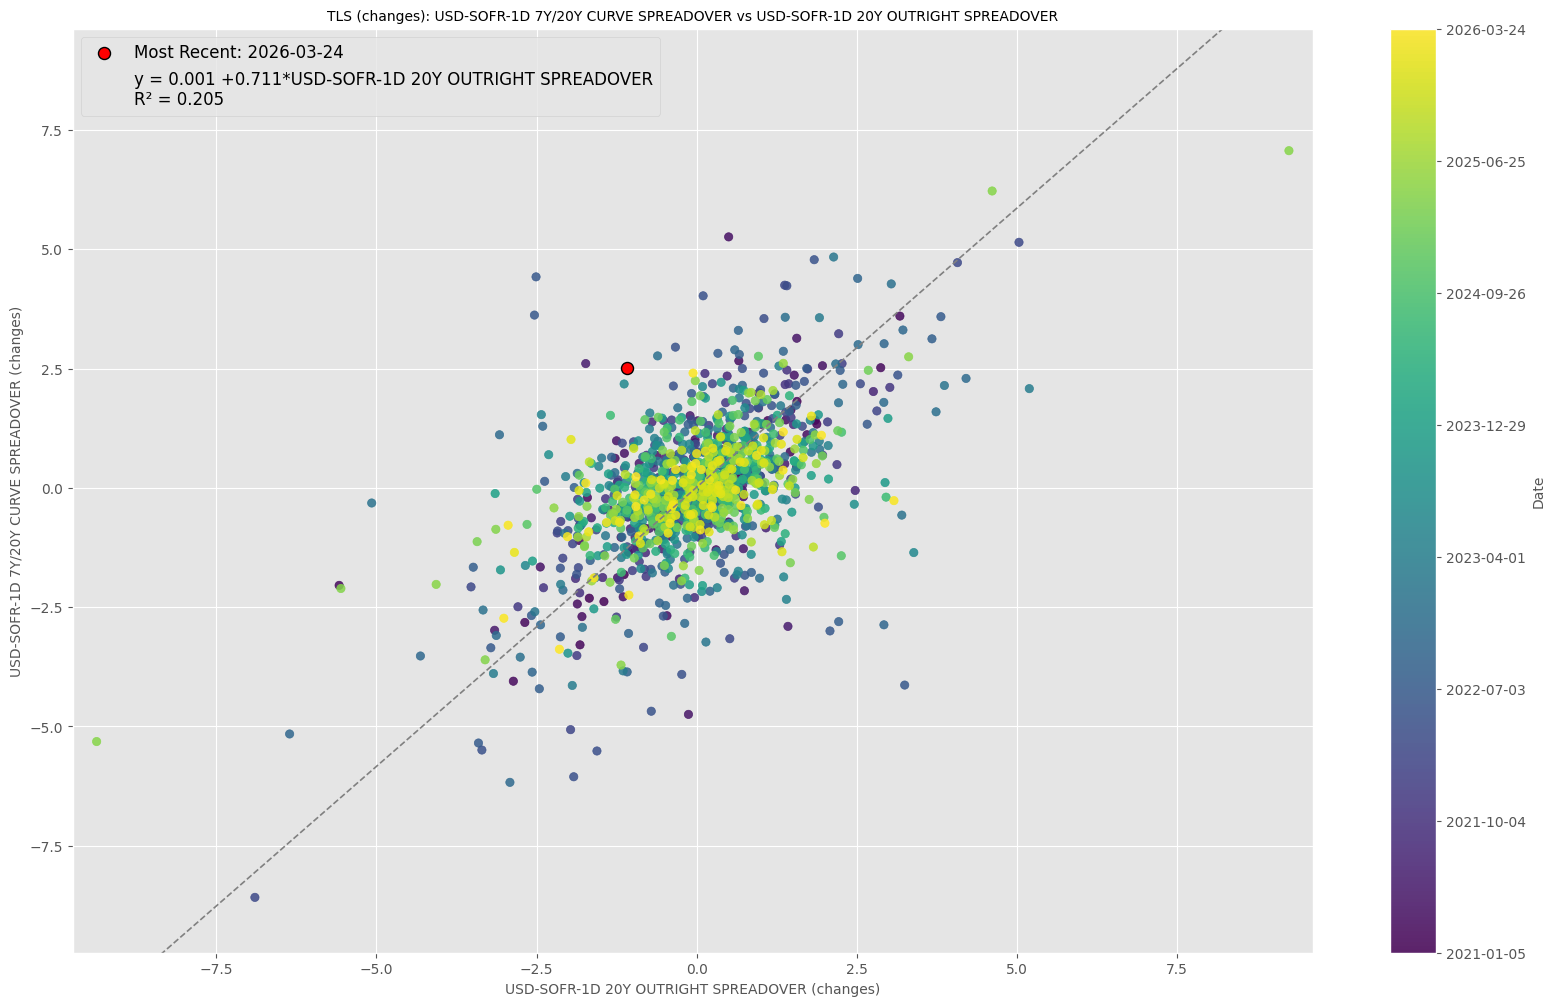

In [31]:
from RVUtils.regression import make_linear_regression_builder
import gs_quant.timeseries.econometrics as gsqtse

add_x, fit_, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
    df=df,
    y_col="USD-SOFR-1D 7Y/20Y CURVE SPREADOVER",
    date_color_bar=True,
    on_diff=True,
    add_constant=True,
)

add_x("USD-SOFR-1D 20Y OUTRIGHT SPREADOVER")
_ = fit_(model="OLS")
X_used, y_used, _ = get_data()
X_no_const = X_used.drop(columns=["const"], errors="ignore")

def rvol_abs(s, w=60, floor=1e-8):
    v = gsqtse.volatility(x=s, w=w, returns_type=gsqtse.Returns.ABSOLUTE)
    return v.reindex(y_used.index).bfill().clip(lower=floor)

sx = np.column_stack([rvol_abs(X_no_const[c]).values for c in X_no_const.columns])
sy = rvol_abs(y_used).values

res_deming = fit_(model="TLS", tls_x_errs=sx, tls_y_errs=sy, verbose=True)
plot_avp()

In [40]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
# seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D 7Y/20Y CURVE SPREADOVER"]].dropna(), window=10)
seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"]].dropna(), window=10)
display(seasonality_df)

fig = go.Figure()

# me_col = f"avg"
me_col = "avg-apr"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

n_last = 12
monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
monthly_cols = sorted(monthly_cols)  # chronological
keep = monthly_cols[-n_last:] if n_last > 0 else []

# keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-10,0.565259,-3.57334,4.703858,-7.711939,8.842457,0.073959,-2.917197,3.065115,-5.908354,6.056272,...,0.831384,-2.231663,1.323029,-3.125625,-4.144058,-2.180415,-0.615674,4.928864,4.331334,0.0
-9,0.448502,-3.457336,4.35434,-7.363174,8.260177,1.344627,-0.410939,3.100192,-2.166504,4.855757,...,-0.048071,-2.295858,1.396814,-0.562424,-3.791398,-2.692858,-0.866518,4.415985,4.407602,-2.435822
-8,0.371686,-3.704369,4.447741,-7.780423,8.523795,-0.276249,-1.268643,0.716144,-2.261036,1.708537,...,2.106658,-1.032345,1.255791,-2.921989,-3.261282,-2.777681,-0.396372,0.410434,4.386588,-5.451962
-7,0.539605,-3.542015,4.621225,-7.623636,8.702845,0.560466,-0.692915,1.813847,-1.946296,3.067229,...,1.605257,0.182472,2.574459,-2.195664,-2.027065,-3.594296,-0.695141,2.073009,4.267922,-6.786189
-6,0.468772,-3.049153,3.986697,-6.567078,7.504622,0.440588,-1.961093,2.842268,-4.362773,5.243948,...,-1.003897,1.590654,1.191157,-3.262338,-1.912055,-3.670136,-0.235742,4.592755,3.680987,-3.969314
-5,0.327445,-3.144172,3.799061,-6.615788,7.270678,0.840748,-1.545152,3.226648,-3.931052,5.612548,...,-2.349383,0.428079,1.808376,-2.571629,-1.465303,-3.397347,0.40234,4.870681,2.412351,-5.492689
-4,0.463858,-2.628711,3.556426,-5.721279,6.648994,1.365344,-0.502995,3.233683,-2.371334,5.102022,...,-2.64356,2.250268,1.110174,-3.139825,-0.095809,-3.32406,0.914543,4.764387,0.432113,<NA>
-3,0.289032,-2.406856,2.98492,-5.102744,5.680809,1.384313,0.605329,2.163297,-0.173654,2.94228,...,-0.919642,1.295401,0.890512,-1.816026,0.041289,-3.214315,1.187008,2.391959,-0.029328,<NA>
-2,0.196711,-2.210115,2.603537,-4.616942,5.010364,1.430709,0.151626,2.709792,-1.127457,3.988875,...,-2.23027,1.823507,-0.252988,-0.679376,-1.340942,-2.43999,1.714861,2.259577,1.867013,<NA>
